# Decision Tree Classifier from Scratch

This notebook implements a Classification Decision Tree from scratch using NumPy.

## Mathematical Foundations
We grow the tree recursively by splitting nodes to maximize **Information Gain** (or minimize impurity).

### Entropy
$$H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i)$$
where $p_i$ is the proportion of samples belonging to class $i$.

### Information Gain
$$IG(S, A) = H(S) - \sum_{t \in T} \frac{|S_t|}{|S|} H(S_t)$$
where split $A$ divides parent set $S$ into child subsets $T$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

## Generate Synthetic Classification Data

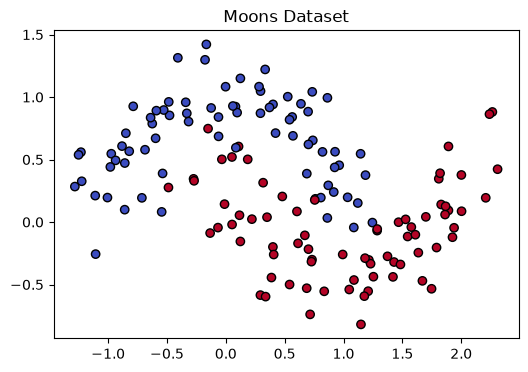

In [2]:
# Simple classification dataset
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=150, noise=0.2, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title('Moons Dataset')
plt.show()

## Decision Tree Implementation

In [3]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, *, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value
        
    def is_leaf(self):
        return self.value is not None

class DecisionTreeFromScratch:
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        
    def fit(self, X, y):
        self.root = self._grow_tree(X, y)
        
    def _grow_tree(self, X, y, depth=0):
        n_samples, n_features = X.shape
        n_labels = len(np.unique(y))
        
        # Check stopping criteria
        if (depth >= self.max_depth or
            n_labels == 1 or
            n_samples < self.min_samples_split):
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
            
        # Find best split
        best_feat, best_thresh = self._best_split(X, y, n_samples, n_features)
        
        if best_feat is None:
            leaf_value = self._most_common_label(y)
            return Node(value=leaf_value)
            
        # Grow children
        left_idx = X[:, best_feat] < best_thresh
        right_idx = ~left_idx
        
        left = self._grow_tree(X[left_idx], y[left_idx], depth+1)
        right = self._grow_tree(X[right_idx], y[right_idx], depth+1)
        return Node(feature=best_feat, threshold=best_thresh, left=left, right=right)
        
    def _best_split(self, X, y, n_samples, n_features):
        best_gain = -1
        split_idx, split_thresh = None, None
        
        for feat_idx in range(n_features):
            X_column = X[:, feat_idx]
            thresholds = np.unique(X_column)
            for threshold in thresholds:
                gain = self._information_gain(y, X_column, threshold)
                if gain > best_gain:
                    best_gain = gain
                    split_idx = feat_idx
                    split_thresh = threshold
                    
        return split_idx, split_thresh
        
    def _information_gain(self, y, X_column, threshold):
        parent_entropy = self._entropy(y)
        
        left_idx = X_column < threshold
        right_idx = ~left_idx
        
        if len(y[left_idx]) == 0 or len(y[right_idx]) == 0:
            return 0
            
        n = len(y)
        n_l, n_r = len(y[left_idx]), len(y[right_idx])
        e_l, e_r = self._entropy(y[left_idx]), self._entropy(y[right_idx])
        child_entropy = (n_l / n) * e_l + (n_r / n) * e_r
        
        return parent_entropy - child_entropy
        
    def _entropy(self, y):
        hist = np.bincount(y)
        ps = hist / len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
        
    def _most_common_label(self, y):
        return np.bincount(y).argmax()
        
    def predict(self, X):
        return np.array([self._traverse_tree(x, self.root) for x in X])
        
    def _traverse_tree(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] < node.threshold:
            return self._traverse_tree(x, node.left)
        return self._traverse_tree(x, node.right)

## Evaluate Model & Plot Decision Boundary

Training Accuracy: 96.00%


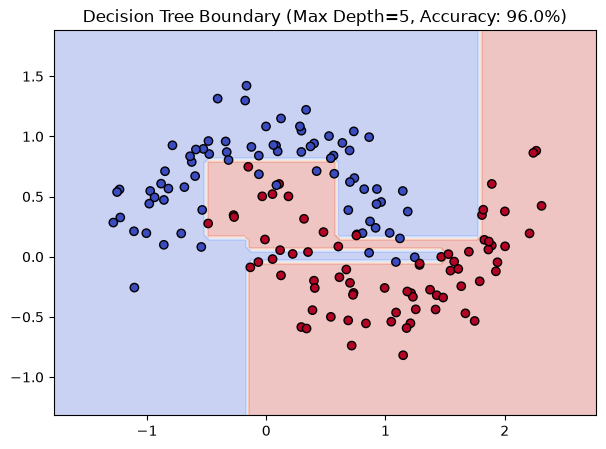

In [4]:
model = DecisionTreeFromScratch(max_depth=5)
model.fit(X, y)

y_pred = model.predict(X)
accuracy = np.mean(y_pred == y)
print(f"Training Accuracy: {accuracy * 100:.2f}%")

# Grid for boundary
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k')
plt.title(f'Decision Tree Boundary (Max Depth=5, Accuracy: {accuracy*100:.1f}%)')
plt.show()